# Lab 4: Regression and Classification Evaluation Metrics

## Aim
To implement the **K-Nearest Neighbours (KNN)** classification algorithm on the **Breast Cancer Wisconsin Diagnostic Dataset**, analyze its performance using different validation techniques, and evaluate the model using classification metrics. The lab also compares these metrics with the regression evaluation metrics studied in **Linear Regression (Lab 3).**

# Task 1 — Data Preparation

## Why Feature Scaling?
KNN calculations are based on distance metrics between data points. Features with larger numerical ranges will dominate these distance calculations, rendering features with smaller ranges ineffective. 

We apply feature scaling using `StandardScaler`. This transforms the distribution of each feature to have:
- **Mean = 0**
- **Standard Deviation = 1**

This ensures that every feature contributes equally to the distance calculation.

### Mapping Target Variable
- `"M"` (predicted class `0` in our setup)
- `"B"` (predicted class `1` in our setup)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
import os

# Set up directories and aesthetics
os.makedirs('../images', exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 10

# Load dataset
# The dataset has an index in the first column, which we read using index_col=0
df = pd.read_csv('data/breast_cancer.csv', index_col=0)

print("--- Dataset Shape & Information ---")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 Rows:")
display(df.head())

print("\n--- Data Types and Non-Null Counts ---")
df.info()

print("\n--- Checking for Missing Values & Duplicates ---")
missing_values = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()
print(f"Total Missing Values: {missing_values}")
print(f"Total Duplicate Rows: {duplicate_rows}")

print("\n--- Target Variable Distribution ---")
class_counts = df['y'].value_counts()
class_props = df['y'].value_counts(normalize=True)
for cls, count in class_counts.items():
    print(f"Class '{cls}': {count} samples ({class_props[cls]*100:.2f}%)")

# Map Target Variable 'y' ('M' -> 0, 'B' -> 1)
df['y'] = df['y'].map({'M': 0, 'B': 1})
print("\nTarget Variable 'y' mapped successfully:")
print(df['y'].value_counts())


--- Dataset Shape & Information ---
Shape: 569 rows, 31 columns

First 5 Rows:


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B



--- Data Types and Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 1 to 569
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-null    float64
 15  x.compactne

# Task 2 — Train-Test Split Analysis

We perform three different train-test splits to evaluate how training set size affects the model:
- **80:20, 70:30, 90:10 Split**

### Feature Scaling
Split **before** scaling to avoid **data leakage**.

- Fit `StandardScaler` only on `X_train`
- Transform both `X_train` and `X_test` with the same scaler

In [2]:
# Separate features and target
X = df.drop(columns=['y'])
y = df['y']

# Define splits to analyze
split_ratios = {
    '80:20': 0.20,
    '70:30': 0.30,
    '90:10': 0.10
}

split_results = []

for split_name, test_size in split_ratios.items():
    # Stratify split ensures that class ratios are preserved in train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # Scale features (Fit only on training, transform both)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Heuristic K = sqrt(n_train), rounded to the nearest odd integer
    n_train = len(X_train)
    heuristic_k = int(np.round(np.sqrt(n_train)))
    if heuristic_k % 2 == 0:
        heuristic_k += 1  # Make odd to prevent ties
        
    # Fit KNN Model
    knn = KNeighborsClassifier(n_neighbors=heuristic_k)
    knn.fit(X_train_scaled, y_train)
    
    # Evaluate
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    split_results.append({
        'Split Ratio': split_name,
        'Train Size (n)': n_train,
        'Test Size': len(X_test),
        'Heuristic K': heuristic_k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

# Compile results in a table
df_splits = pd.DataFrame(split_results)
print("--- Comparison of Different Train-Test Splits ---")
display(df_splits)


--- Comparison of Different Train-Test Splits ---


,Split Ratio,Train Size (n),Test Size,Heuristic K,Accuracy,Precision,Recall,F1 Score
0,80:20,455,114,21,0.964912,0.947368,1.0,0.972973
1,70:30,398,171,21,0.947368,0.922414,1.0,0.959641
2,90:10,512,57,23,0.982456,0.972973,1.0,0.986301


### Analysis: Effect of Train-Test Split on Performance

1. **90:10 Split**
   - More training data, so the model learns better.
   - Very small test set, so results may vary more.

2. **70:30 Split**
   - Less training data, so performance may drop slightly.
   - Larger test set gives more stable evaluation.

3. **80:20 Split**
   - Best balance between training size and test size.
   - Suitable for both learning and evaluation.


# Task 3 — KNN Model Optimization

## Step 1: Heuristic K Selection
Use the rule of thumb:
* Using square root of `n`

For the 80:20 split:
* n = 445 | k = square_root(445) | = 21

We use the nearest odd integer to avoid ties.

## Step 2: Test Different K Values
To find a better value, we evaluate a range of K values from 1 to 35 and compare the test accuracy to the heuristic choice.

Heuristic K: 21 (Test Accuracy: 96.49%)
Optimal K from Parameter Search: 3 (Test Accuracy: 98.25%)


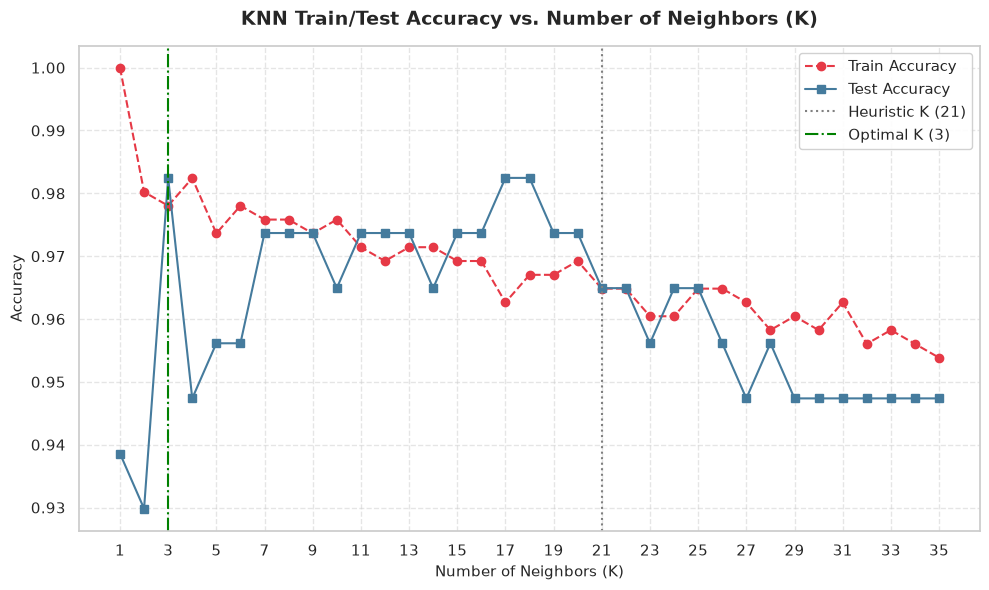

In [3]:
# Standardize 80:20 split for optimization
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = list(range(1, 36))
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

# Find best K
best_idx = np.argmax(test_accuracies)
best_k = k_values[best_idx]
best_test_acc = test_accuracies[best_idx]

print(f"Heuristic K: 21 (Test Accuracy: {test_accuracies[k_values.index(21)]*100:.2f}%)")
print(f"Optimal K from Parameter Search: {best_k} (Test Accuracy: {best_test_acc*100:.2f}%)")

# Plot Train & Test Accuracy vs K
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(k_values, train_accuracies, label='Train Accuracy', color='#E63946', marker='o', linestyle='--')
plt.plot(k_values, test_accuracies, label='Test Accuracy', color='#457B9D', marker='s')
plt.axvline(x=21, color='gray', linestyle=':', label='Heuristic K (21)')
plt.axvline(x=best_k, color='green', linestyle='-.', label=f'Optimal K ({best_k})')

plt.title('KNN Train/Test Accuracy vs. Number of Neighbors (K)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Neighbors (K)', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.xticks(k_values[::2])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig('../images/accuracy_vs_k.png', dpi=150)
plt.show()


## Distance Metrics in KNN

Distance metrics tell KNN how close two data points are.

- **Euclidean Distance (L2):** Measures the straight-line distance between two points. Best for numerical data.

- **Manhattan Distance (L1):** Measures distance by moving along rows and columns. It is less affected by outliers.

In [4]:
# Compare distance metrics with the optimal K value
metrics_comp = []

for metric_name in ['euclidean', 'manhattan']:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric_name)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    metrics_comp.append({
        'Distance Metric': metric_name.capitalize(),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

df_metrics = pd.DataFrame(metrics_comp)
print("--- Distance Metric Comparison Table ---")
display(df_metrics)


--- Distance Metric Comparison Table ---


,Distance Metric,Accuracy,Precision,Recall,F1 Score
0,Euclidean,0.982456,0.972973,1.000000,0.986301
1,Manhattan,0.964912,0.959459,0.986111,0.972603


## Decision Boundary Visualization

Our dataset has 30 features, so we cannot directly draw the decision boundary. To make it easier to visualize, we use **PCA** to reduce the data to **2 dimensions**.

We then train KNN models with different values of **K (1, 5, 10, and 20)** and compare their decision boundaries.

- **Small K (e.g., 1):** Creates complex boundaries and may overfit the training data.
- **Large K (e.g., 20):** Creates smoother boundaries but may underfit the data.

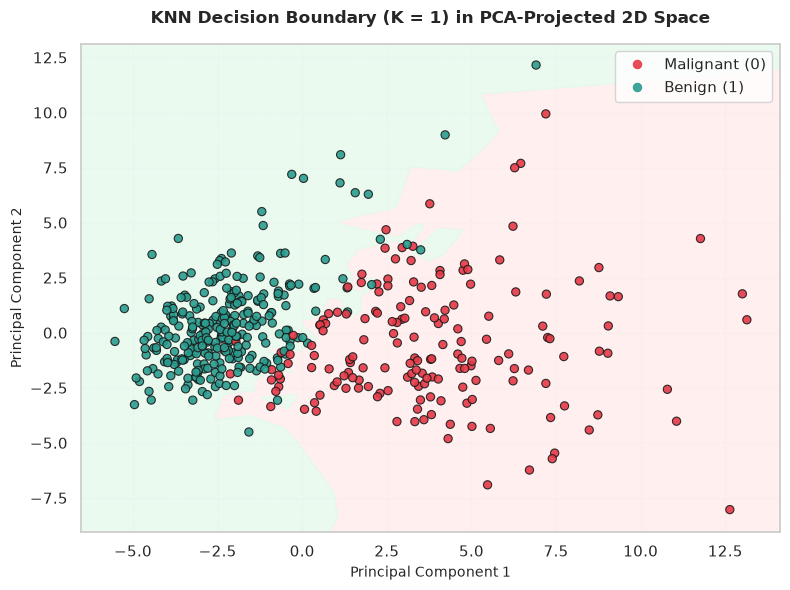

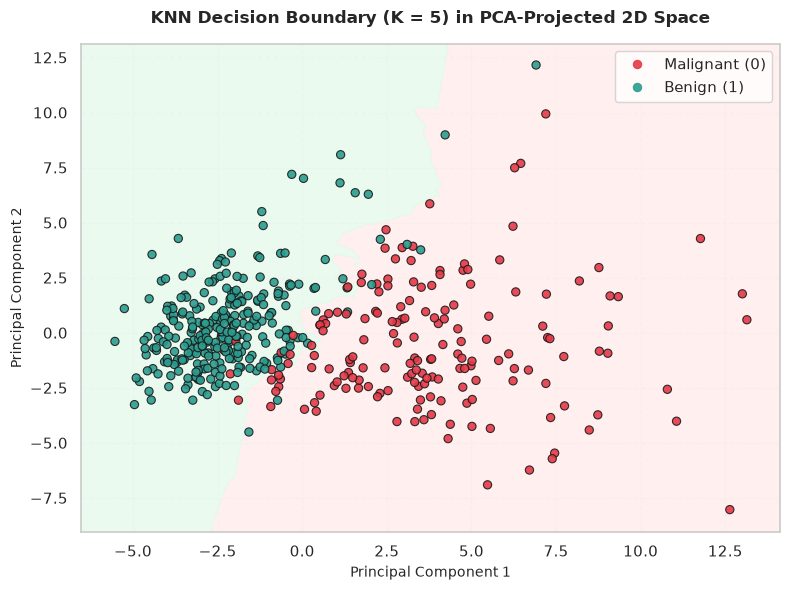

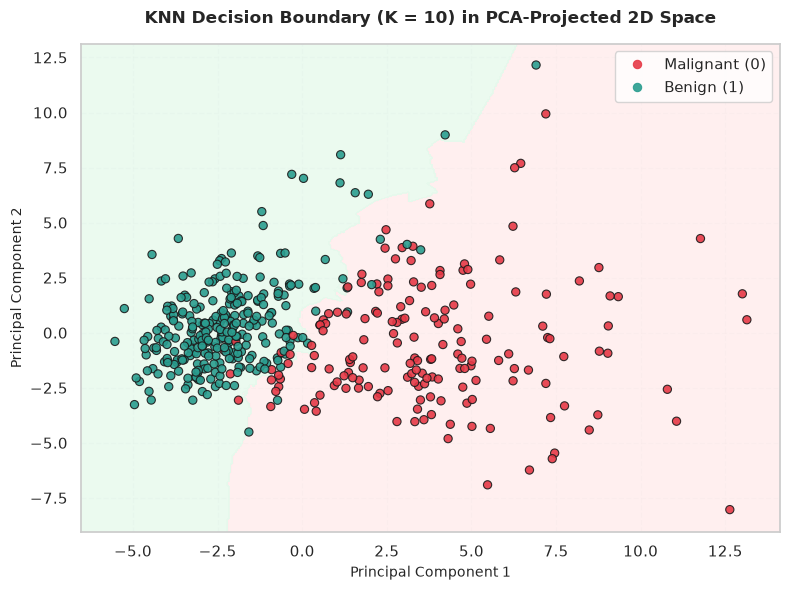

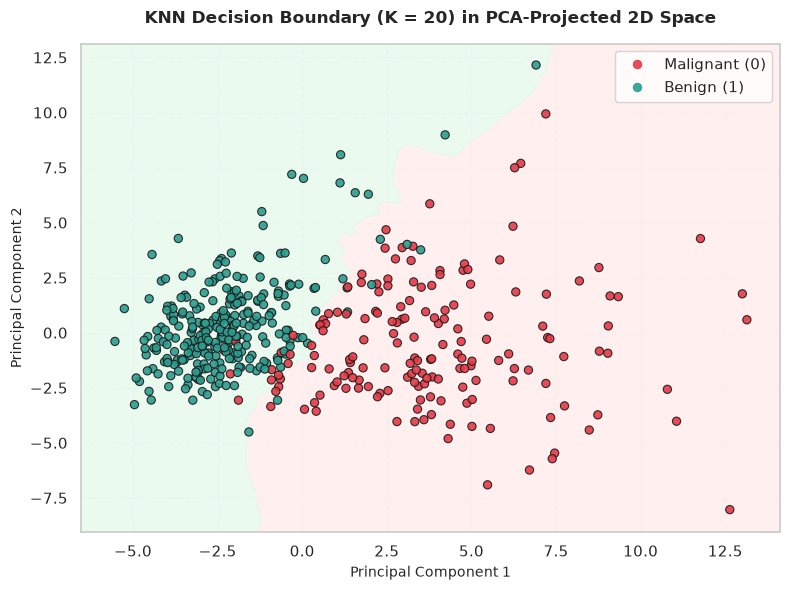

In [5]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Project scaled features to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

k_list = [1, 5, 10, 20]
cmap_light = ListedColormap(['#FFECEC', '#E6F9EC']) # Very light red and green
cmap_bold = ['#E63946', '#2A9D8F'] # Professional Crimson and Teal

for K in k_list:
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_train_pca, y_train)
    
    # Setup boundary mesh grid
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6), dpi=100)
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    
    # Scatter plot
    scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
                          cmap=ListedColormap(cmap_bold), edgecolor='k', s=35, alpha=0.9, linewidth=0.8)
    
    plt.title(f'KNN Decision Boundary (K = {K}) in PCA-Projected 2D Space', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Principal Component 1', fontsize=10)
    plt.ylabel('Principal Component 2', fontsize=10)
    
    # Legend
    handles, labels = scatter.legend_elements()
    plt.legend(handles, ['Malignant (0)', 'Benign (1)'], loc='upper right', frameon=True)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # Save image
    plt.savefig(f'../images/decision_boundary_k{K}.png', dpi=150)
    plt.show()


# Task 4 — Cross Validation

Cross Validation helps us test the model on different parts of the dataset instead of using only one train-test split. We use **5-Fold** and **10-Fold Cross Validation** to get a more reliable evaluation.

### Preventing Data Leakage

To avoid data leakage, we scale the data separately within each fold. This ensures the model only learns from the training data in each fold. We use scikit-learn's **Pipeline** to do this automatically.

In [6]:
from sklearn.pipeline import Pipeline

cv_results = {}

for folds in [5, 10]:
    # Setup pipeline with scaling and model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k))
    ])
    
    scores = cross_val_score(pipeline, X, y, cv=folds, scoring='accuracy')
    cv_results[f'{folds}-Fold'] = scores
    print(f"{folds}-Fold Cross Validation Mean Accuracy: {scores.mean()*100:.2f}% (± {scores.std()*100:.2f}%)")

# Compare with simple train-test split accuracy
print(f"Simple 80:20 Split Test Accuracy (Optimal K = {best_k}): {best_test_acc*100:.2f}%")


5-Fold Cross Validation Mean Accuracy: 95.95% (± 1.91%)
10-Fold Cross Validation Mean Accuracy: 96.65% (± 2.16%)
Simple 80:20 Split Test Accuracy (Optimal K = 3): 98.25%


# Task 5 — Model Evaluation

We evaluate the final KNN model using different performance metrics:

- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** How many predicted positive cases are actually positive.
- **Recall:** How many actual positive cases are correctly identified.
- **F1 Score:** A balance between Precision and Recall.
- **Confusion Matrix:** Shows correct and incorrect predictions.
- **ROC Curve & ROC-AUC:** Measures how well the model separates the two classes.

--- Classification Report ---
               precision    recall  f1-score   support

Malignant (0)       1.00      0.95      0.98        42
   Benign (1)       0.97      1.00      0.99        72

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



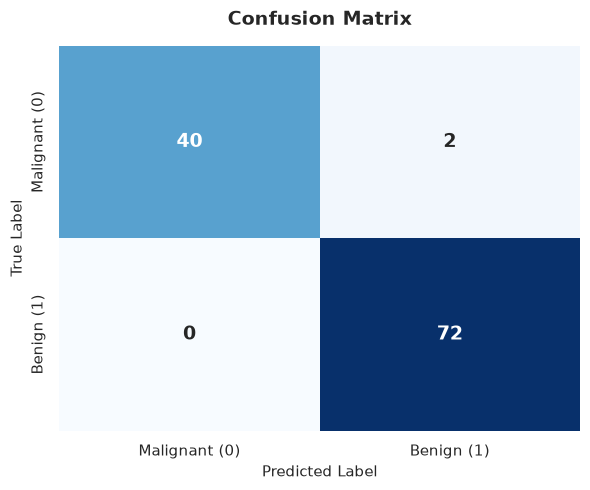

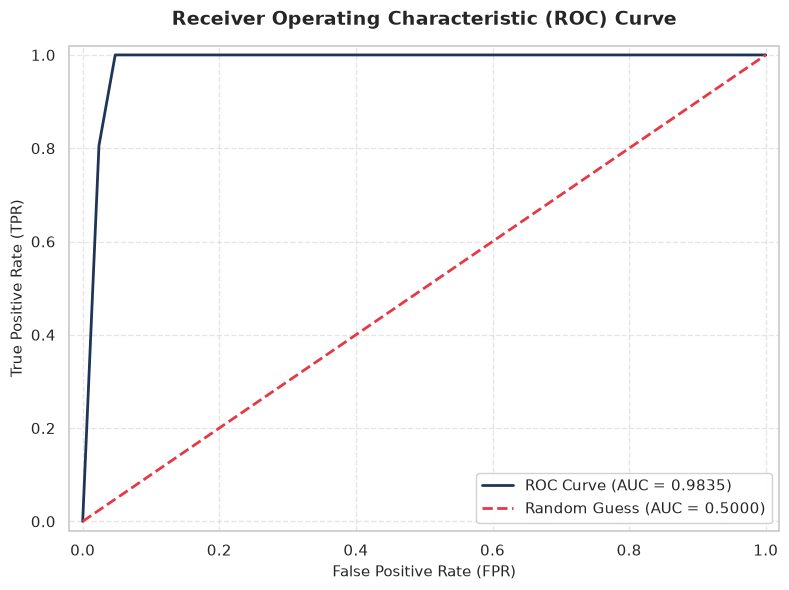

In [7]:
# Fit the final model with optimal K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

y_pred = final_knn.predict(X_test_scaled)
y_pred_proba = final_knn.predict_proba(X_test_scaled)[:, 1]

# 1. Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5), dpi=100)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=150)
plt.show()

# 3. ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6), dpi=100)
plt.plot(fpr, tpr, color='#1D3557', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#E63946', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig('../images/roc_curve.png', dpi=150)
plt.show()


# Task 6 — Regression vs Classification

| Property | Regression | Classification |
| :--- | :--- | :--- |
| **Output** | Numerical values | Categories or classes |
| **Goal** | Predict a value | Predict the correct class |
| **Common Metrics** | MAE, MSE, RMSE, R² | Accuracy, Precision, Recall, F1 Score, ROC-AUC |

---

## Comparison

### 1. R² Score vs Accuracy
- **R² Score:** Measures how well the model predicts numerical values.
- **Accuracy:** Measures the percentage of correct class predictions.

### 2. RMSE vs F1 Score
- **RMSE:** Measures the average prediction error in regression.
- **F1 Score:** Balances Precision and Recall for classification.

### 3. MAE vs Confusion Matrix
- **MAE:** Measures the average absolute error in regression.
- **Confusion Matrix:** Shows the number of correct and incorrect predictions for each class.

# Analytical Questions

### 1. Why is KNN called a lazy learning algorithm?
KNN is called a lazy learning algorithm because it does not learn a model during training. It simply stores the training data and makes predictions only when new data is given.

### 2. Why is feature scaling necessary?
Feature scaling ensures that all features have a similar range. This prevents features with larger values from having a bigger influence on distance calculations.

### 3. How is the value of K selected?
A common starting point is **K = √n** (where *n* is the number of training samples). The best value is then chosen by testing different K values and selecting the one with the highest accuracy.

### 4. Why is cross validation more reliable?
Cross validation tests the model on different parts of the dataset, giving a more reliable estimate of its performance than a single train-test split.

### 5. Explain the bias-variance trade-off using K.
- **Small K:** Can overfit the data by learning noise.
- **Large K:** Can underfit the data by oversimplifying patterns.
- **Optimal K:** Balances both to achieve good performance.

### 6. Why is Recall more important than Accuracy in cancer diagnosis?
Recall measures how many actual cancer cases are correctly detected. Missing a cancer patient is much more serious than incorrectly predicting cancer for a healthy person.

### 7. What happens when K becomes very large?
When K is very large, the model considers too many neighbors and often predicts the majority class, leading to underfitting.

# Conclusion

In this lab, we implemented the K-Nearest Neighbours (KNN) algorithm to classify breast cancer cases. We prepared the data, scaled the features, tested different values of **K**, and evaluated the model using cross-validation and classification metrics such as Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC. The results showed the importance of feature scaling and selecting the right value of **K** for better performance.

---

# References

1. UCI Machine Learning Repository – Breast Cancer Wisconsin Dataset.
2. Scikit-Learn Documentation.
3. ROC Curve and AUC Documentation.
4. Lab 3 – Linear Regression Evaluation Metrics.